........loaded data........
                                                 App        category  \
0     Photo Editor & Candy Camera & Grid & ScrapBook  ART_AND_DESIGN   
1                                Coloring book moana  ART_AND_DESIGN   
2  U Launcher Lite – FREE Live Cool Themes, Hide ...  ART_AND_DESIGN   
3                              Sketch - Draw & Paint  ART_AND_DESIGN   
4              Pixel Draw - Number Art Coloring Book  ART_AND_DESIGN   

   installs  rating  size_mb  days_since_update  type  price  monthly_revenue  \
0     10000     4.1     19.0                213  Free    0.0           1000.0   
1    500000     3.9     14.0                205  Free    0.0          50000.0   
2   5000000     4.7      8.7                  7  Free    0.0         500000.0   
3  50000000     4.5     25.0                 61  Free    0.0        5000000.0   
4    100000     4.3      2.8                 49  Free    0.0          10000.0   

   predicted_monthly_revenue  
0               1.386

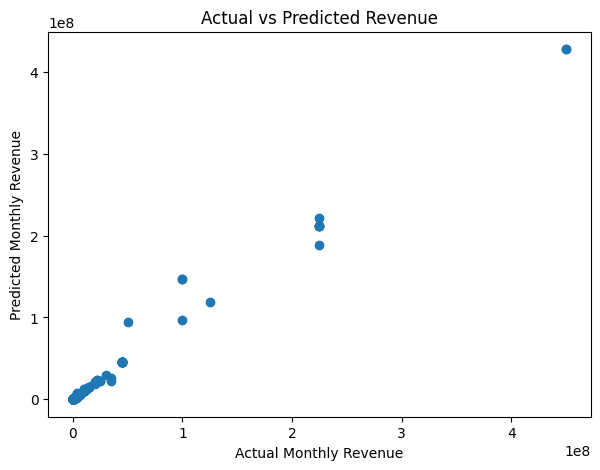

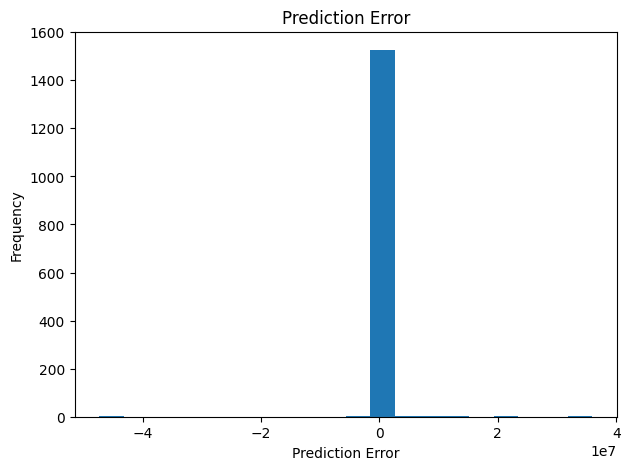

..........feature importance..........
             Feature  Importance
2       log_installs    0.398096
1           installs    0.361414
4            size_mb    0.170713
0           category    0.055094
5  days_since_update    0.013505
3             rating    0.000615
7              price    0.000561
6               type    0.000003


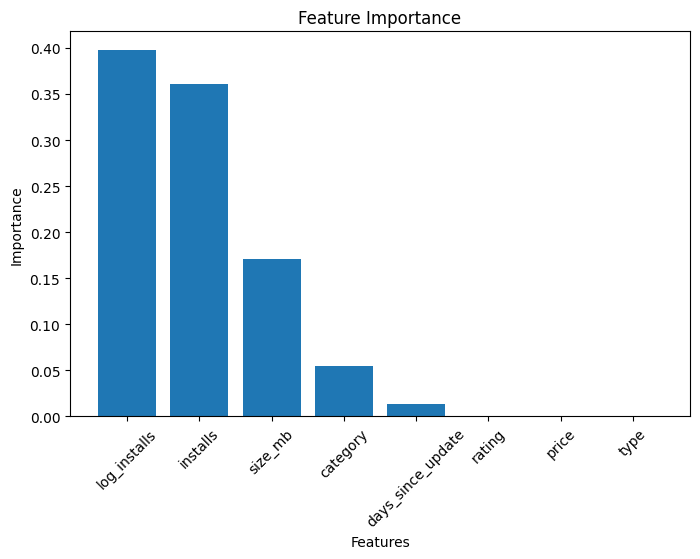

..........new app prediction..........
Predicted Monthly Revenue: 224838.42980280126


In [ ]:
# ============================================================
# IMPORT REQUIRED LIBRARIES
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor

from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error
from sklearn.metrics import r2_score


# ============================================================
# LOAD DATASET
# ============================================================

print("........loaded data........")

df = pd.read_csv(
    r"/content/predicted_revenue_linear.csv"
)

print(df.head())


# ============================================================
# SHAPE
# ============================================================

print("..........shape..........")

print(df.shape)


# ============================================================
# COLUMNS
# ============================================================

print("..........columns..........")

print(df.columns)


# ============================================================
# INFORMATION
# ============================================================

print("..........information..........")

df.info()


# ============================================================
# STATISTICAL SUMMARY
# ============================================================

print("..........statistical summary..........")

print(df.describe())


# ============================================================
# MISSING VALUES
# ============================================================

print("..........missing values..........")

print(df.isnull().sum())


# ============================================================
# REMOVE MISSING VALUES
# ============================================================

print("..........remove missing values..........")

df = df.dropna()

print(df.isnull().sum())


# ============================================================
# REMOVE UNWANTED COLUMNS
# ============================================================

print("..........remove unwanted columns..........")

# App = application name
# predicted_monthly_revenue = previous prediction
# Remove both to avoid unwanted information/data leakage

df = df.drop(
    ["App", "predicted_monthly_revenue"],
    axis=1
)

print(df.head())


# ============================================================
# FEATURE ENGINEERING
# ============================================================

print("..........feature engineering..........")

# Revenue may have a nonlinear relationship with installs.
# log_installs can help the model learn that relationship.

df["log_installs"] = np.log1p(
    df["installs"]
)

print(df.head())


# ============================================================
# INPUT FEATURES AND TARGET
# ============================================================

print("..........input and target..........")

inputs = df[
    [
        "category",
        "installs",
        "log_installs",
        "rating",
        "size_mb",
        "days_since_update",
        "type",
        "price"
    ]
].copy()

target = df["monthly_revenue"]


print("Input Features:")

print(inputs.head())


print("\nTarget:")

print(target.head())


# ============================================================
# LABEL ENCODING
# ============================================================

print("..........label encoding..........")

category_encoder = LabelEncoder()

inputs["category"] = category_encoder.fit_transform(
    inputs["category"]
)


type_encoder = LabelEncoder()

inputs["type"] = type_encoder.fit_transform(
    inputs["type"]
)


print(inputs.head())


# ============================================================
# TRAIN TEST SPLIT
# ============================================================

print("..........train test split..........")

inputs_train, inputs_test, target_train, target_test = train_test_split(
    inputs,
    target,
    test_size=0.2,
    random_state=42
)

print("Training data:", inputs_train.shape)

print("Testing data:", inputs_test.shape)


# ============================================================
# CREATE RANDOM FOREST REGRESSION MODEL
# ============================================================

print("..........random forest regression..........")

model = RandomForestRegressor(
    n_estimators=300,
    max_depth=15,
    min_samples_split=5,
    min_samples_leaf=2,
    random_state=42,
    n_jobs=-1
)


# ============================================================
# TRAIN MODEL
# ============================================================

print("..........training model..........")

model.fit(
    inputs_train,
    target_train
)

print("Model training completed")


# ============================================================
# MODEL PREDICTION
# ============================================================

print("..........model prediction..........")

prediction = model.predict(
    inputs_test
)

print("First 10 predicted values:")

print(prediction[:10])


# ============================================================
# MODEL SCORE
# ============================================================

print("..........model score..........")

train_r2 = model.score(
    inputs_train,
    target_train
)

test_r2 = model.score(
    inputs_test,
    target_test
)


print("Training R2 Score:", train_r2)

print("Testing R2 Score:", test_r2)


# ============================================================
# MODEL ACCURACY
# ============================================================

print("..........model accuracy..........")

accuracy = test_r2 * 100

print(
    "Model Accuracy:",
    round(accuracy, 2),
    "%"
)


# ============================================================
# REGRESSION EVALUATION
# ============================================================

print("..........model evaluation..........")

mae = mean_absolute_error(
    target_test,
    prediction
)

mse = mean_squared_error(
    target_test,
    prediction
)

rmse = np.sqrt(mse)

r2 = r2_score(
    target_test,
    prediction
)


print("Mean Absolute Error:", mae)

print("Mean Squared Error:", mse)

print("Root Mean Squared Error:", rmse)

print("R2 Score:", r2)


# ============================================================
# ACTUAL VS PREDICTED
# ============================================================

print("..........actual vs predicted..........")

result = pd.DataFrame({

    "Actual Revenue": target_test.values,

    "Predicted Revenue": prediction

})

print(result.head(10))


# ============================================================
# ACTUAL VS PREDICTED GRAPH
# ============================================================

plt.figure(figsize=(7, 5))

plt.scatter(
    target_test,
    prediction
)

plt.xlabel("Actual Monthly Revenue")

plt.ylabel("Predicted Monthly Revenue")

plt.title("Actual vs Predicted Revenue")

plt.show()


# ============================================================
# PREDICTION ERROR
# ============================================================

error = target_test.values - prediction

plt.figure(figsize=(7, 5))

plt.hist(
    error,
    bins=20
)

plt.xlabel("Prediction Error")

plt.ylabel("Frequency")

plt.title("Prediction Error")

plt.show()


# ============================================================
# FEATURE IMPORTANCE
# ============================================================

print("..........feature importance..........")

feature_names = [
    "category",
    "installs",
    "log_installs",
    "rating",
    "size_mb",
    "days_since_update",
    "type",
    "price"
]

importance = pd.DataFrame({

    "Feature": feature_names,

    "Importance": model.feature_importances_

})

importance = importance.sort_values(
    by="Importance",
    ascending=False
)

print(importance)


# ============================================================
# FEATURE IMPORTANCE GRAPH
# ============================================================

plt.figure(figsize=(8, 5))

plt.bar(
    importance["Feature"],
    importance["Importance"]
)

plt.xlabel("Features")

plt.ylabel("Importance")

plt.title("Feature Importance")

plt.xticks(rotation=45)

plt.show()


# ============================================================
# NEW APP REVENUE PREDICTION
# ============================================================

print("..........new app prediction..........")

# Example:
# category = GAME
# installs = 500000
# rating = 4.5
# size_mb = 25
# days_since_update = 30
# type = Free
# price = 0

new_app = pd.DataFrame({

    "category": ["GAME"],

    "installs": [500000],

    "log_installs": [
        np.log1p(500000)
    ],

    "rating": [4.5],

    "size_mb": [25],

    "days_since_update": [30],

    "type": ["Free"],

    "price": [0]

})


# Encode category

new_app["category"] = category_encoder.transform(
    new_app["category"]
)


# Encode type

new_app["type"] = type_encoder.transform(
    new_app["type"]
)


# Predict revenue

new_revenue = model.predict(
    new_app
)


print(
    "Predicted Monthly Revenue:",
    new_revenue[0]
)